In [55]:

# Import Libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)

In [56]:

# Generate Dataset

rows = 12000

data = {
    "Patient_ID": range(1, rows+1),
    "Pregnancies": np.random.randint(0, 11, rows),
    "Glucose": np.random.randint(70, 220, rows),
    "BloodPressure": np.random.randint(60, 110, rows),
    "BP_Category": np.random.choice(["Low", "Normal", "High"], rows),
    "SkinThickness": np.random.randint(10, 60, rows),
    "Insulin": np.random.randint(15, 350, rows),
    "BMI": np.round(np.random.uniform(16.0, 50.0, rows), 1),
    "Age": np.random.randint(18, 80, rows),
    "HeartDisease": np.random.choice([0, 1], rows),
    "FamilyHistory": np.random.choice([0, 1], rows),
    "Smoking": np.random.choice([0, 1], rows),
    "AlcoholIntake": np.random.choice([0, 1, 2], rows),
    "DietScore": np.random.randint(1, 10, rows),
    "FrequentUrination": np.random.choice([0, 1], rows),
    "ExcessiveThirst": np.random.choice([0, 1], rows),
    "Fatigue": np.random.choice([0, 1], rows),
    "BlurredVision": np.random.choice([0, 1], rows)
}

df = pd.DataFrame(data)

df.head()

,Patient_ID,Pregnancies,Glucose,BloodPressure,BP_Category,SkinThickness,Insulin,BMI,Age,HeartDisease,FamilyHistory,Smoking,AlcoholIntake,DietScore,FrequentUrination,ExcessiveThirst,Fatigue,BlurredVision
0,1,6,115,97,High,44,345,32.0,41,1,0,1,1,4,0,0,1,0
1,2,3,84,104,Normal,26,261,23.2,21,0,1,0,0,1,0,0,1,1
2,3,10,199,98,High,35,246,45.0,64,1,1,1,2,9,1,1,1,1
3,4,7,130,60,Normal,30,306,39.1,67,0,0,1,2,5,0,0,1,1
4,5,4,184,81,Low,21,184,19.2,52,0,1,1,0,9,1,0,0,1


In [57]:

#  BMI Categorization


def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

df.drop("BMI", axis=1, inplace=True)

df.head()

,Patient_ID,Pregnancies,Glucose,BloodPressure,BP_Category,SkinThickness,Insulin,Age,HeartDisease,FamilyHistory,Smoking,AlcoholIntake,DietScore,FrequentUrination,ExcessiveThirst,Fatigue,BlurredVision,BMI_Category
0,1,6,115,97,High,44,345,41,1,0,1,1,4,0,0,1,0,Obese
1,2,3,84,104,Normal,26,261,21,0,1,0,0,1,0,0,1,1,Normal
2,3,10,199,98,High,35,246,64,1,1,1,2,9,1,1,1,1,Obese
3,4,7,130,60,Normal,30,306,67,0,0,1,2,5,0,0,1,1,Obese
4,5,4,184,81,Low,21,184,52,0,1,1,0,9,1,0,0,1,Normal


In [58]:

# Create Target Variable


def calculate_outcome(row):
    score = 0

    if row["Glucose"] > 150:
        score += 2

    if row["Age"] > 50:
        score += 1

    if row["BloodPressure"] > 90:
        score += 1

    if row["Insulin"] > 200:
        score += 1

    if row["HeartDisease"] == 1:
        score += 1

    if row["FamilyHistory"] == 1:
        score += 2

    if row["FrequentUrination"] == 1:
        score += 1

    if row["ExcessiveThirst"] == 1:
        score += 1

    # Add randomness
    score += np.random.randint(-2, 3)

    return 1 if score >= 4 else 0

df["Outcome"] = df.apply(calculate_outcome, axis=1)

df.head()

,Patient_ID,Pregnancies,Glucose,BloodPressure,BP_Category,SkinThickness,Insulin,Age,HeartDisease,FamilyHistory,Smoking,AlcoholIntake,DietScore,FrequentUrination,ExcessiveThirst,Fatigue,BlurredVision,BMI_Category,Outcome
0,1,6,115,97,High,44,345,41,1,0,1,1,4,0,0,1,0,Obese,0
1,2,3,84,104,Normal,26,261,21,0,1,0,0,1,0,0,1,1,Normal,0
2,3,10,199,98,High,35,246,64,1,1,1,2,9,1,1,1,1,Obese,1
3,4,7,130,60,Normal,30,306,67,0,0,1,2,5,0,0,1,1,Obese,0
4,5,4,184,81,Low,21,184,52,0,1,1,0,9,1,0,0,1,Normal,1


In [59]:

#Handle Missing Values

# Fill numeric missing values
df = df.fillna(df.median(numeric_only=True))

# Fill categorical missing values
df = df.fillna(df.mode().iloc[0])

df.isnull().sum()

Patient_ID           0
Pregnancies          0
Glucose              0
BloodPressure        0
BP_Category          0
SkinThickness        0
Insulin              0
Age                  0
HeartDisease         0
FamilyHistory        0
Smoking              0
AlcoholIntake        0
DietScore            0
FrequentUrination    0
ExcessiveThirst      0
Fatigue              0
BlurredVision        0
BMI_Category         0
Outcome              0
dtype: int64

In [60]:

#  Encode Categorical Variables


df = pd.get_dummies(
    df,
    columns=["BP_Category", "BMI_Category"],
    drop_first=True
)

df.head()

,Patient_ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,Age,HeartDisease,FamilyHistory,Smoking,...,FrequentUrination,ExcessiveThirst,Fatigue,BlurredVision,Outcome,BP_Category_Low,BP_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight
0,1,6,115,97,44,345,41,1,0,1,...,0,0,1,0,0,False,False,True,False,False
1,2,3,84,104,26,261,21,0,1,0,...,0,0,1,1,0,False,True,False,False,False
2,3,10,199,98,35,246,64,1,1,1,...,1,1,1,1,1,False,False,True,False,False
3,4,7,130,60,30,306,67,0,0,1,...,0,0,1,1,0,False,True,True,False,False
4,5,4,184,81,21,184,52,0,1,1,...,1,0,0,1,1,True,False,False,False,False


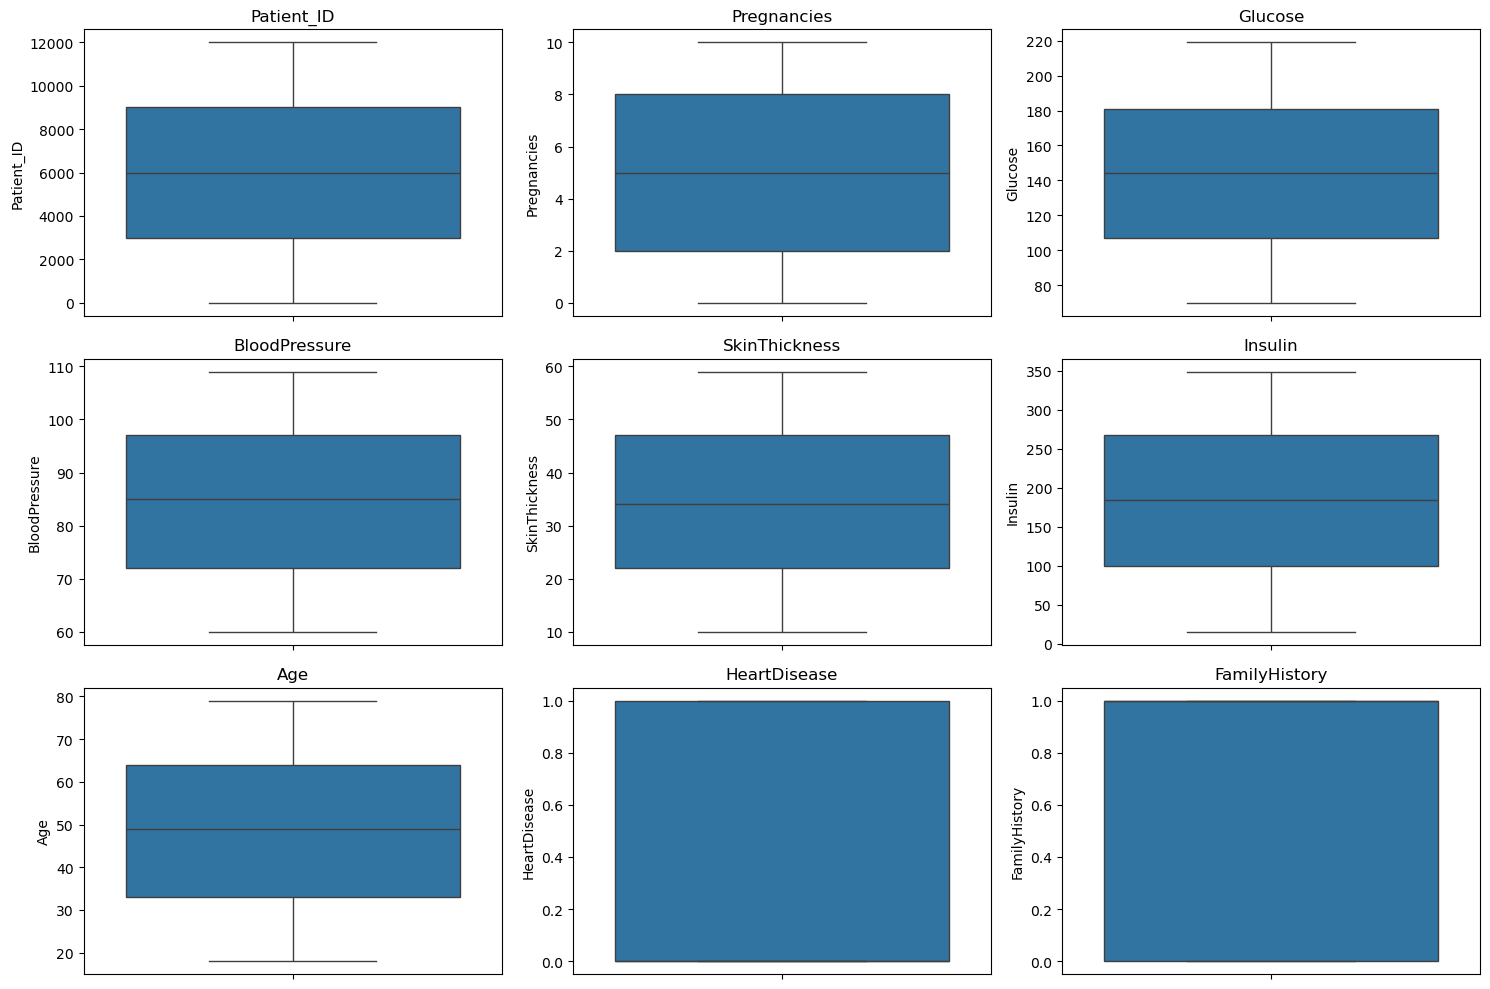

In [61]:

#  Boxplot Visualization


num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols[:9]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [62]:

#  Outlier Removal using IQR


Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        (
            (df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR))
        ).any(axis=1)
    )
]

print("After outlier removal:", df.shape)

After outlier removal: (12000, 22)


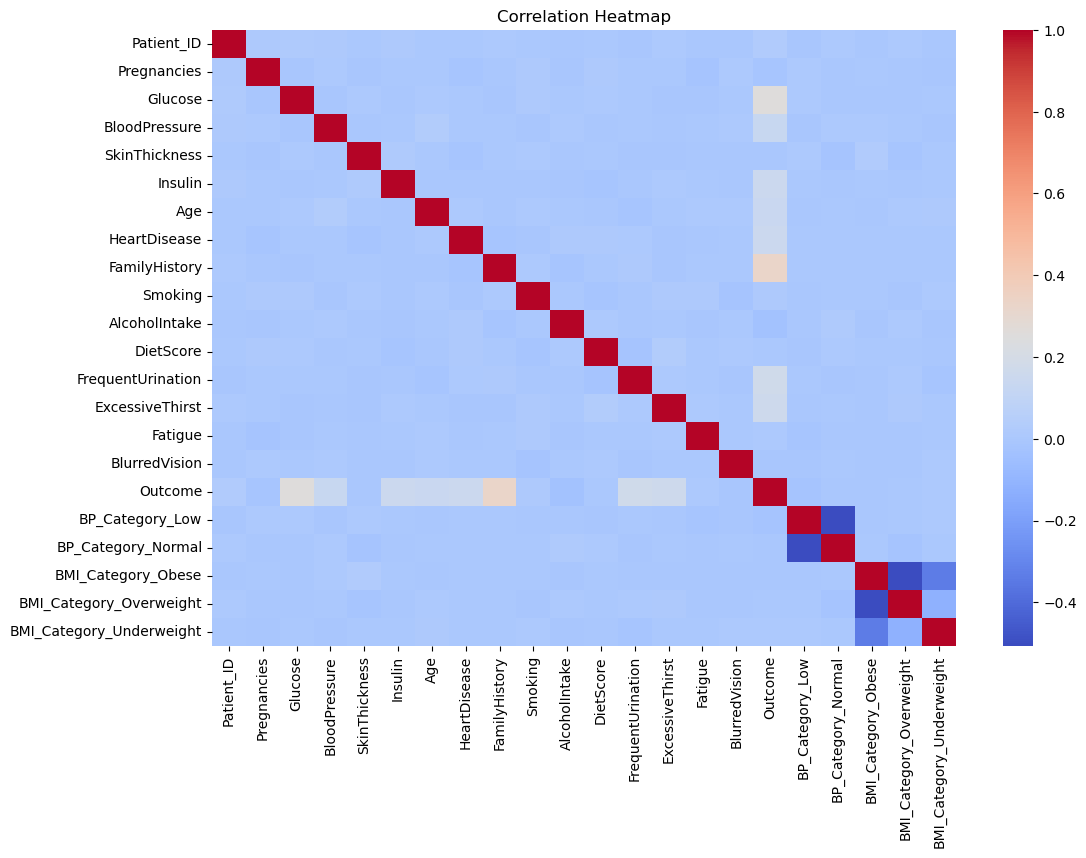

In [63]:

#  Correlation Heatmap


plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [64]:

#  Feature Selection


corr = df.corr()["Outcome"].abs().sort_values(ascending=False)

selected_features = corr[1:15].index

print("Selected Features:\n")
print(selected_features)

Selected Features:

Index(['FamilyHistory', 'Glucose', 'FrequentUrination', 'ExcessiveThirst',
       'Insulin', 'HeartDisease', 'Age', 'BloodPressure', 'AlcoholIntake',
       'Patient_ID', 'BP_Category_Low', 'Smoking', 'Pregnancies',
       'BlurredVision'],
      dtype='object')


In [65]:

#  Save Dataset


df.to_csv("db_risk.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [66]:

# Define Features and Target


X = df[selected_features]

y = df["Outcome"]

X.head()

,FamilyHistory,Glucose,FrequentUrination,ExcessiveThirst,Insulin,HeartDisease,Age,BloodPressure,AlcoholIntake,Patient_ID,BP_Category_Low,Smoking,Pregnancies,BlurredVision
0,0,115,0,0,345,1,41,97,1,1,False,1,6,0
1,1,84,0,0,261,0,21,104,0,2,False,0,3,1
2,1,199,1,1,246,1,64,98,2,3,False,1,10,1
3,0,130,0,0,306,0,67,60,2,4,False,1,7,1
4,1,184,1,0,184,0,52,81,0,5,True,1,4,1


In [67]:

#  Train-Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9600, 14)
(2400, 14)


In [68]:

# Missing Value Imputation


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)

X_test = imputer.transform(X_test)

In [69]:

#  Feature Scaling


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [70]:

#  Import ML Models


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [71]:

#  Hyperparameter Tuning


from sklearn.model_selection import GridSearchCV

# Random Forest Tuning
rf_params = {
    "n_estimators": [200],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_model = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)


# Logistic Regression Tuning
lr_params = {
    "C": [0.1, 1, 10]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=3000),
    lr_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

lr_model = lr_grid.best_estimator_

print("Best LR Params:", lr_grid.best_params_)


# KNN Tuning
knn_params = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

knn_model = knn_grid.best_estimator_

print("Best KNN Params:", knn_grid.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best LR Params: {'C': 0.1}
Best KNN Params: {'n_neighbors': 7, 'weights': 'uniform'}


In [72]:

# Support Vector Machine (SVM)

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


🔹 Random Forest Evaluation
Accuracy: 0.7991666666666667
Precision: 0.8110871905274488
Recall: 0.92002442002442
F1 Score: 0.8621281464530892
ROC-AUC: 0.8758288226792164

Confusion Matrix:

[[ 411  351]
 [ 131 1507]]

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.54      0.63       762
           1       0.81      0.92      0.86      1638

    accuracy                           0.80      2400
   macro avg       0.78      0.73      0.75      2400
weighted avg       0.79      0.80      0.79      2400



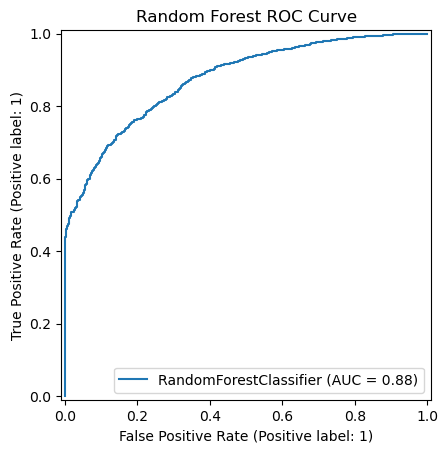

In [73]:

#  Random Forest 


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("🔹 Random Forest Evaluation")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

plt.title("Random Forest ROC Curve")

plt.show()

🔹 Logistic Regression Evaluation
Accuracy: 0.7908333333333334
Precision: 0.8103825136612022
Recall: 0.9053724053724054
F1 Score: 0.8552479815455594
ROC-AUC: 0.8566549373635988

Confusion Matrix:

[[ 415  347]
 [ 155 1483]]

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.54      0.62       762
           1       0.81      0.91      0.86      1638

    accuracy                           0.79      2400
   macro avg       0.77      0.72      0.74      2400
weighted avg       0.78      0.79      0.78      2400



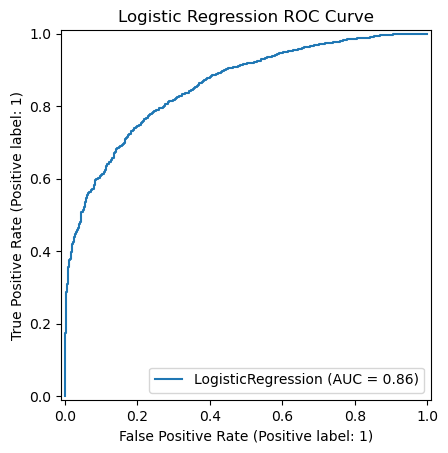

In [74]:

#  Logistic Regression 


y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("🔹 Logistic Regression Evaluation")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

plt.title("Logistic Regression ROC Curve")

plt.show()

🔹 KNN Evaluation
Accuracy: 0.7629166666666667
Precision: 0.7997756590016826
Recall: 0.8705738705738706
F1 Score: 0.8336743642209881
ROC-AUC: 0.7967697948012908

Confusion Matrix:

[[ 405  357]
 [ 212 1426]]

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.53      0.59       762
           1       0.80      0.87      0.83      1638

    accuracy                           0.76      2400
   macro avg       0.73      0.70      0.71      2400
weighted avg       0.75      0.76      0.76      2400



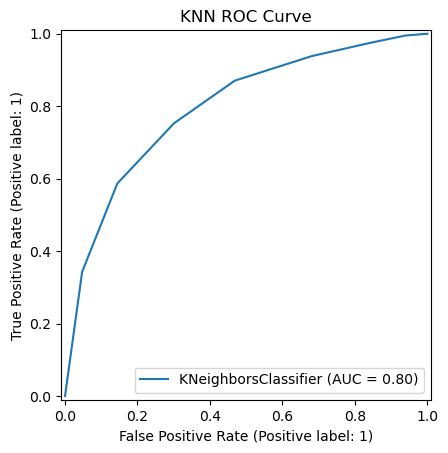

In [75]:

# KNN Evaluation


y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

print("🔹 KNN Evaluation")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

RocCurveDisplay.from_estimator(knn_model, X_test, y_test)

plt.title("KNN ROC Curve")

plt.show()

🔹 SVM Evaluation
Accuracy: 0.77875
Precision: 0.816105082809823
Recall: 0.8724053724053724
F1 Score: 0.8433166125700796
ROC-AUC: 0.8293963254593175

Confusion Matrix:

[[ 440  322]
 [ 209 1429]]

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.58      0.62       762
           1       0.82      0.87      0.84      1638

    accuracy                           0.78      2400
   macro avg       0.75      0.72      0.73      2400
weighted avg       0.77      0.78      0.77      2400



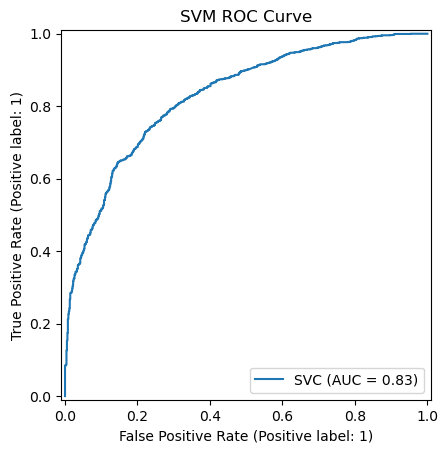

In [76]:

# SVM Evaluation


y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("🔹 SVM Evaluation")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

RocCurveDisplay.from_estimator(svm_model, X_test, y_test)

plt.title("SVM ROC Curve")

plt.show()

In [77]:
# =========================
# CELL 24 : Compare All Models
# =========================

results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_svm)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.799167,0.811087,0.920024,0.862128,0.875829
1,Logistic Regression,0.790833,0.810383,0.905372,0.855248,0.856655
3,SVM,0.778750,0.816105,0.872405,0.843317,0.829396
2,KNN,0.762917,0.799776,0.870574,0.833674,0.796770


In [82]:

#  Take Input from User

print("Enter Patient Details:\n")

# Numeric Inputs
Patient_ID = int(input("Patient ID: "))
Pregnancies = int(input("Pregnancies: "))
Glucose = float(input("Glucose Level: "))
BloodPressure = float(input("Blood Pressure: "))
SkinThickness = float(input("Skin Thickness: "))
Insulin = float(input("Insulin Level: "))
Age = int(input("Age: "))
HeartDisease = int(input("Heart Disease (0/1): "))
FamilyHistory = int(input("Family History (0/1): "))
Smoking = int(input("Smoking (0/1): "))
AlcoholIntake = int(input("Alcohol Intake (0=None, 1=Moderate, 2=High): "))
DietScore = int(input("Diet Score (1-10): "))
FrequentUrination = int(input("Frequent Urination (0/1): "))
ExcessiveThirst = int(input("Excessive Thirst (0/1): "))
Fatigue = int(input("Fatigue (0/1): "))
BlurredVision = int(input("Blurred Vision (0/1): "))

# BP Category
bp_category = input("BP Category (Low/Normal/High): ")

# BMI Category
bmi_category = input("BMI Category (Underweight/Normal/Overweight/Obese): ")

# Create dictionary
sample_data = {

    "Patient_ID": Patient_ID,
    "Pregnancies": Pregnancies,
    "Glucose": Glucose,
    "BloodPressure": BloodPressure,
    "SkinThickness": SkinThickness,
    "Insulin": Insulin,
    "Age": Age,
    "HeartDisease": HeartDisease,
    "FamilyHistory": FamilyHistory,
    "Smoking": Smoking,
    "AlcoholIntake": AlcoholIntake,
    "DietScore": DietScore,
    "FrequentUrination": FrequentUrination,
    "ExcessiveThirst": ExcessiveThirst,
    "Fatigue": Fatigue,
    "BlurredVision": BlurredVision,

    # One-hot encoded columns
    "BP_Category_Low": 1 if bp_category == "Low" else 0,
    "BP_Category_Normal": 1 if bp_category == "Normal" else 0,

    "BMI_Category_Normal": 1 if bmi_category == "Normal" else 0,
    "BMI_Category_Obese": 1 if bmi_category == "Obese" else 0,
    "BMI_Category_Overweight": 1 if bmi_category == "Overweight" else 0
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_data])

# Add missing columns automatically
for col in selected_features:
    if col not in sample_df.columns:
        sample_df[col] = 0

# Keep only selected features
sample_df = sample_df[selected_features]

# Apply preprocessing
sample_df = imputer.transform(sample_df)
sample_df = scaler.transform(sample_df)

print("\nInput Processed Successfully")

Enter Patient Details:



Patient ID:  02
Pregnancies:  2
Glucose Level:  2
Blood Pressure:  2
Skin Thickness:  2
Insulin Level:  2
Age:  2
Heart Disease (0/1):  1
Family History (0/1):  1
Smoking (0/1):  1
Alcohol Intake (0=None, 1=Moderate, 2=High):  1
Diet Score (1-10):  1
Frequent Urination (0/1):  1
Excessive Thirst (0/1):  1
Fatigue (0/1):  1
Blurred Vision (0/1):  1
BP Category (Low/Normal/High):  High
BMI Category (Underweight/Normal/Overweight/Obese):  Obese



Input Processed Successfully


In [83]:

# Predict using All Models


# Random Forest Prediction
rf_pred = rf_model.predict(sample_df)[0]
rf_prob = rf_model.predict_proba(sample_df)[0][1]

# Logistic Regression Prediction
lr_pred = lr_model.predict(sample_df)[0]
lr_prob = lr_model.predict_proba(sample_df)[0][1]

# KNN Prediction
knn_pred = knn_model.predict(sample_df)[0]
knn_prob = knn_model.predict_proba(sample_df)[0][1]

# SVM Prediction
svm_pred = svm_model.predict(sample_df)[0]
svm_prob = svm_model.predict_proba(sample_df)[0][1]



print("Predictions Completed")

Predictions Completed


In [80]:

#  Display Results


results_df = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],

    "Prediction": [
        rf_pred,
        lr_pred,
        knn_pred,
        svm_pred
    ],

    "Probability of Diabetes": [
        rf_prob,
        lr_prob,
        knn_prob,
        svm_prob
    ]
})

results_df

,Model,Prediction,Probability of Diabetes
0,Random Forest,1,0.517819
1,Logistic Regression,0,0.031154
2,KNN,1,0.571429
3,SVM,1,0.781369


In [81]:

#  Final Prediction


final_prediction = round(np.mean([
    rf_pred,
    lr_pred,
    knn_pred,
    svm_pred
]))

if final_prediction == 1:
    print("\n HIGH Diabetes Risk Detected")
else:
    print("\n LOW Diabetes Risk Detected")


 HIGH Diabetes Risk Detected
